* Student: Diego Bernal
* Id:1257853

### Report

## Part 1: Basic Model

* dataset:Fruit Image Dataset: Fresh and Rotten Fruits
* model: CNN

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
import copy
import time

### - Data preprocessing

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


dataset_root = '../data'


train_dataset_full = datasets.ImageFolder(root=f'{dataset_root}/train', transform=train_transforms)
test_dataset = datasets.ImageFolder(root=f'{dataset_root}/test', transform=test_transforms)


val_size = int(0.1 * len(train_dataset_full))
train_size = len(train_dataset_full) - val_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])
val_dataset.dataset.transform = test_transforms  # sin data augmentation en validación


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset_full.classes
print("Clases:", class_names)

Clases: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


### - Model selection (CNN)

In [11]:
class FruitClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super(FruitClassifierCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

num_classes = len(class_names)
model = FruitClassifierCNN(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

FruitClassifierCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=32768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)

### - Training

In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10, patience=3):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Evaluación en validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}: Train loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping activado")
                break

    model.load_state_dict(best_model_wts)
    return model, history

### - Hyperparameter tuning

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rates = [0.001, 0.0005]
batch_sizes = [16, 32]
num_epochs = 10 

results = {}  

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nLearning rate = {lr} and batch size = {bs}")

        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader   = DataLoader(val_dataset, batch_size=bs, shuffle=False)
        
        model = FruitClassifierCNN(num_classes)
        model.to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        inicio = time.time()
        model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=num_epochs, patience=3)
        duracion = time.time() - inicio
        
        best_val_acc = max(history['val_acc'])
        results[(lr, bs)] = {'history': history, 'best_val_acc': best_val_acc, 'training_time': duracion}
        
        print(f"Resultado para lr={lr}, batch_size={bs}: Mejor Val Acc = {best_val_acc:.4f}, Tiempo de entrenamiento = {duracion:.2f} s")

# results
print("\nSummary of Hyperparameter Tuning:")
for (lr, bs), result in results.items():
    print(f"Learning Rate: {lr}, Batch Size: {bs}, Mejor Val Acc: {result['best_val_acc']:.4f}, Tiempo: {result['training_time']:.2f} s")



Learning rate = 0.001 and batch size = 16
Epoch 1/10: Train loss=0.7186, Train Acc=0.7302, Val loss=0.2623, Val Acc=0.9165
Epoch 2/10: Train loss=0.2940, Train Acc=0.8981, Val loss=0.2371, Val Acc=0.9009
Epoch 3/10: Train loss=0.2038, Train Acc=0.9289, Val loss=0.2072, Val Acc=0.9229
Epoch 4/10: Train loss=0.1724, Train Acc=0.9412, Val loss=0.1547, Val Acc=0.9468
Epoch 5/10: Train loss=0.1574, Train Acc=0.9474, Val loss=0.1304, Val Acc=0.9550
Epoch 6/10: Train loss=0.1158, Train Acc=0.9593, Val loss=0.0977, Val Acc=0.9752
Epoch 7/10: Train loss=0.1103, Train Acc=0.9632, Val loss=0.1360, Val Acc=0.9505
Epoch 8/10: Train loss=0.1050, Train Acc=0.9632, Val loss=0.0992, Val Acc=0.9661
Epoch 9/10: Train loss=0.0835, Train Acc=0.9723, Val loss=0.0991, Val Acc=0.9569
Early stopping activado
Resultado para lr=0.001, batch_size=16: Mejor Val Acc = 0.9752, Tiempo de entrenamiento = 564.67 s

Learning rate = 0.001 and batch size = 32
Epoch 1/10: Train loss=0.5777, Train Acc=0.7839, Val loss=0.31

### - Evaluation

In [14]:
best_params = max(results, key=lambda x: results[x]['best_val_acc'])
print(f"\nMejor combinación de hiperparámetros: Learning Rate: {best_params[0]}, Batch Size: {best_params[1]}")


train_loader = DataLoader(train_dataset, batch_size=best_params[1], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=best_params[1], shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=best_params[1], shuffle=False)

model = FruitClassifierCNN(num_classes)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params[0])
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5)

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nReport Clasification in Test:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Mejor combinación de hiperparámetros: Learning Rate: 0.0005, Batch Size: 32
Epoch 1/25: Train loss=0.6234, Train Acc=0.7714, Val loss=0.3217, Val Acc=0.8798
Epoch 2/25: Train loss=0.2676, Train Acc=0.9061, Val loss=0.2222, Val Acc=0.9174
Epoch 3/25: Train loss=0.1943, Train Acc=0.9308, Val loss=0.1762, Val Acc=0.9321
Epoch 4/25: Train loss=0.1522, Train Acc=0.9469, Val loss=0.1141, Val Acc=0.9624
Epoch 5/25: Train loss=0.1347, Train Acc=0.9504, Val loss=0.1113, Val Acc=0.9587
Epoch 6/25: Train loss=0.0993, Train Acc=0.9642, Val loss=0.0725, Val Acc=0.9679
Epoch 7/25: Train loss=0.0855, Train Acc=0.9708, Val loss=0.0674, Val Acc=0.9761
Epoch 8/25: Train loss=0.0848, Train Acc=0.9681, Val loss=0.0873, Val Acc=0.9688
Epoch 9/25: Train loss=0.0686, Train Acc=0.9772, Val loss=0.0532, Val Acc=0.9835
Epoch 10/25: Train loss=0.0547, Train Acc=0.9812, Val loss=0.0482, Val Acc=0.9835
Epoch 11/25: Train loss=0.0404, Train Acc=0.9872, Val loss=0.0694, Val Acc=0.9798
Epoch 12/25: Train loss=0.0438

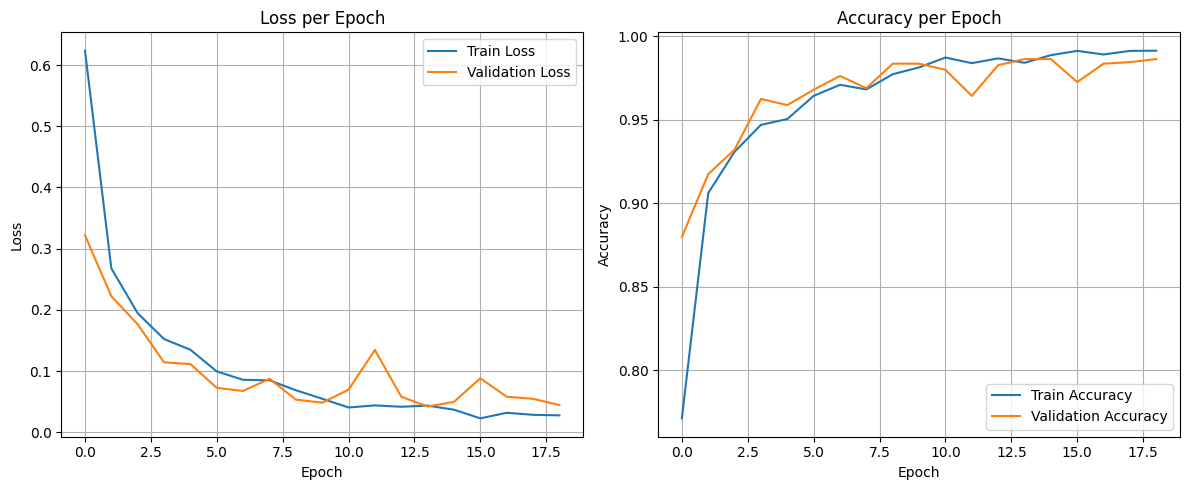

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
torch.save(model.state_dict(), 'modelBasic.pth')